In [15]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_path = r"C:\Users\USER\Desktop\parkinson-detection-cnn-lstm\data\raw_audio\neurovoz\zenodo_upload\audios\PD_O1_0014.wav"

y, sr = librosa.load(audio_path, sr=None)

print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.2f}s")
print(f"Min amplitude: {y.min():.4f}")
print(f"Max amplitude: {y.max():.4f}")
print(f"RMS: {np.sqrt(np.mean(y**2)):.6f}")

Sample rate: 44100
Duration: 4.50s
Min amplitude: -1.0000
Max amplitude: 1.0000
RMS: 0.480584


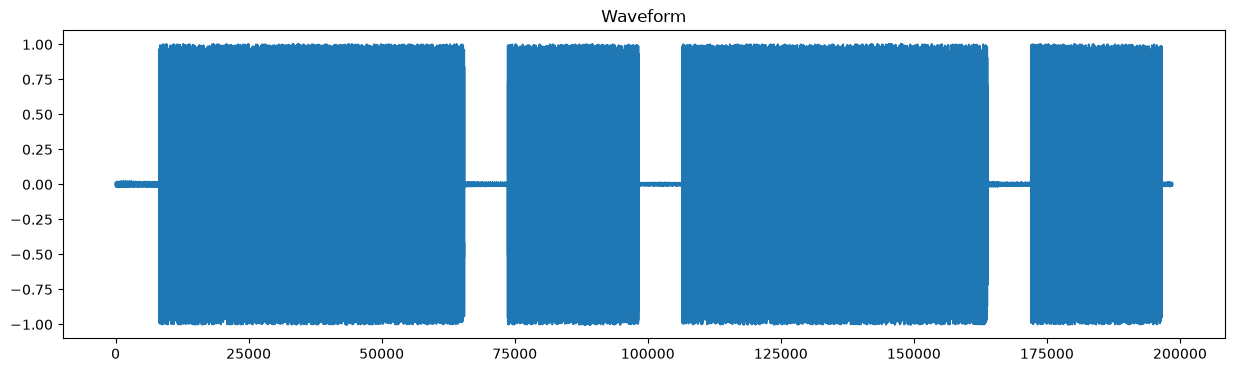

In [16]:
plt.figure(figsize=(15,4))
plt.plot(y)
plt.title("Waveform")
plt.show()

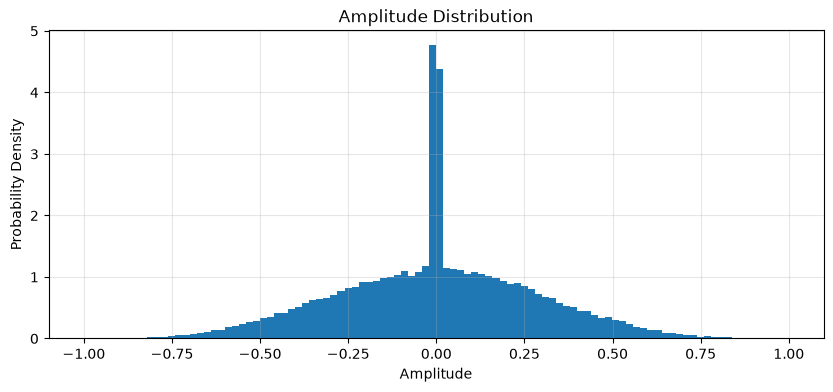

In [7]:
# plt.figure(figsize=(10,4))
# plt.hist(y, bins=100)
# plt.title("Amplitude Histogram")
# plt.show()
plt.figure(figsize=(10,4))
plt.hist(y, bins=100, density=True)
plt.xlabel("Amplitude")
plt.ylabel("Probability Density")
plt.title("Amplitude Distribution")
plt.grid(alpha=0.3)
plt.show()

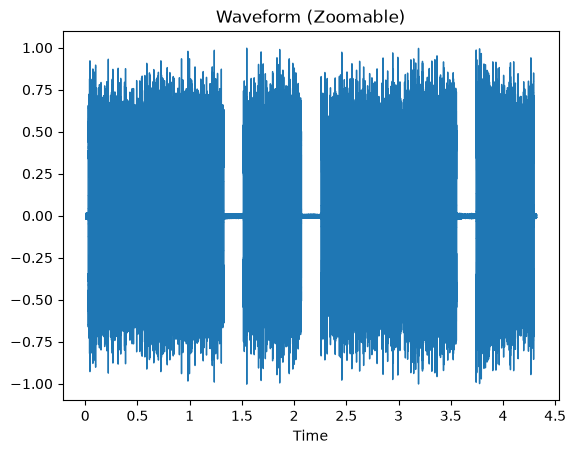

In [8]:
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform (Zoomable)")
plt.show()

In [9]:
num_pos = np.sum(y > 0.99)
num_neg = np.sum(y < -0.99)

print(num_pos)
print(num_neg)
print(len(y))

2
2
69103


In [6]:
print(num_pos / len(y))
print(num_neg / len(y))

0.0034042210326472853
0.0037063708284443817


In [7]:
# np.sum(np.abs(y) > 0.99) / len(y)
print(y.min())
print(y.max())
np.sum(np.abs(y) > 0.99)

-1.0
0.9999695


np.int64(1412)

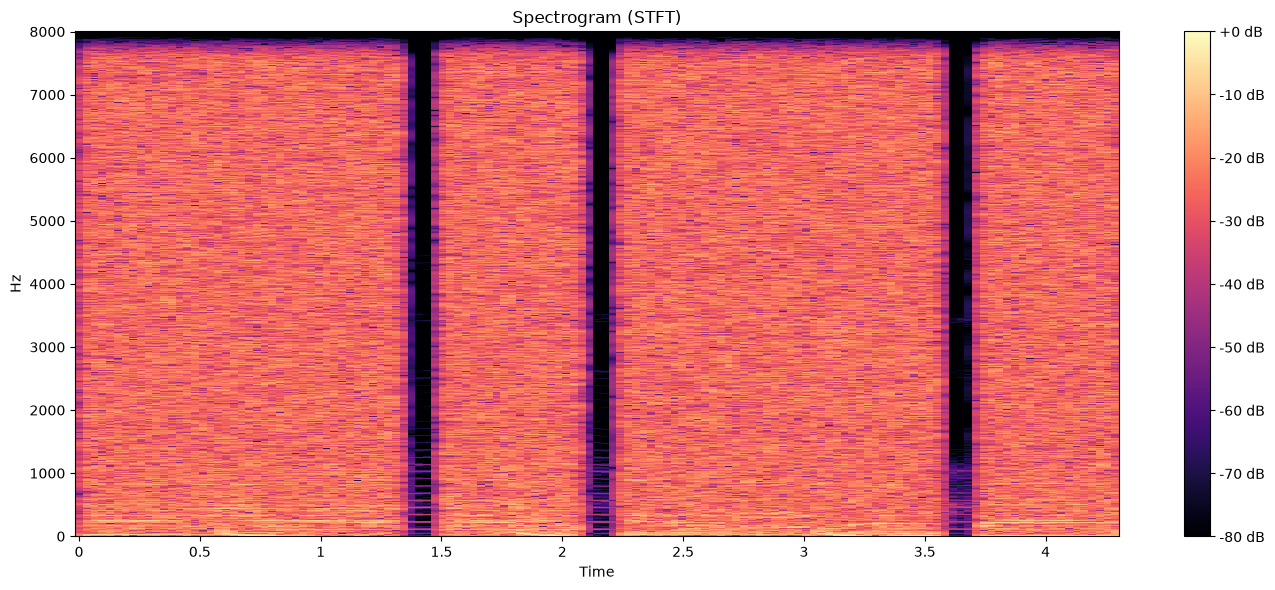

In [10]:
# Compute STFT
D = librosa.stft(
    y,
    n_fft=2048,
    hop_length=512,
    window="hann"
)

# Convert to dB
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

# Plot
plt.figure(figsize=(14, 6))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (STFT)")
plt.tight_layout()
plt.show()

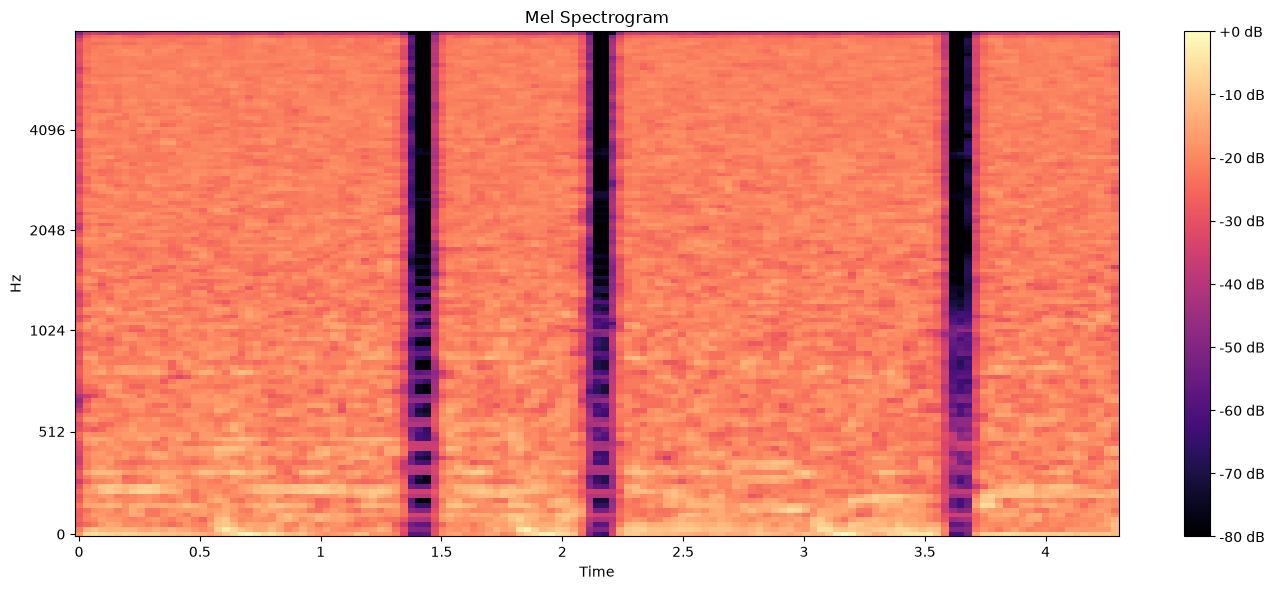

In [11]:
# Compute Mel spectrogram
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    power=2.0
)

# Convert to dB
mel_db = librosa.power_to_db(mel, ref=np.max)

# Plot
plt.figure(figsize=(14, 6))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

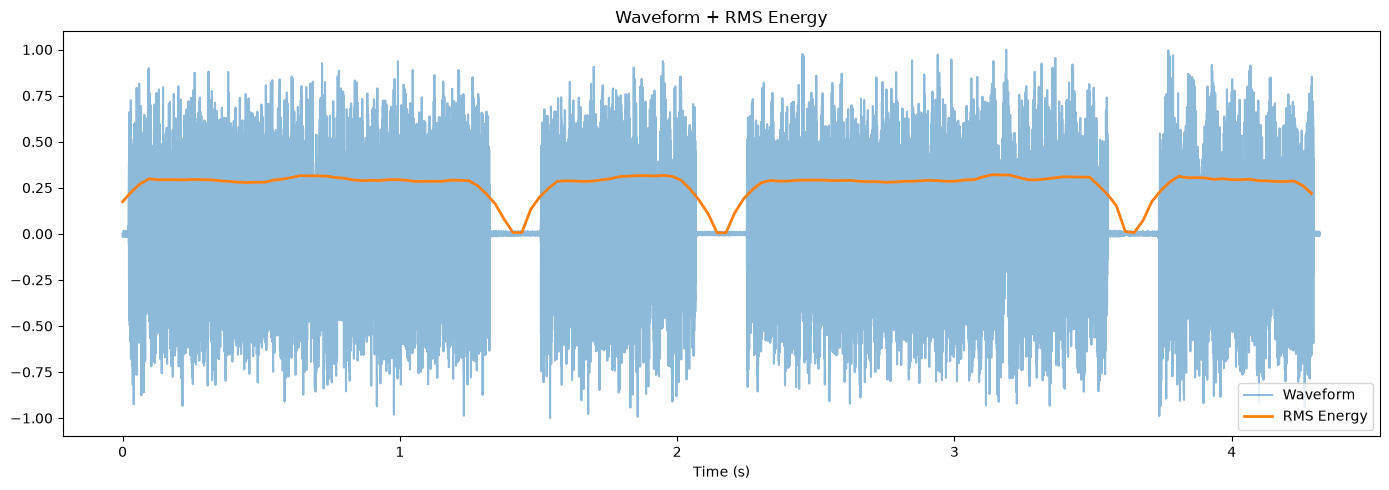

In [12]:
rms = librosa.feature.rms(
    y=y,
    frame_length=2048,
    hop_length=512
)[0]

times = librosa.times_like(rms, sr=sr, hop_length=512)

plt.figure(figsize=(14,5))
plt.plot(np.arange(len(y))/sr, y, alpha=0.5, label="Waveform")
plt.plot(times, rms, linewidth=2, label="RMS Energy")
plt.xlabel("Time (s)")
plt.legend()
plt.title("Waveform + RMS Energy")
plt.tight_layout()
plt.show()

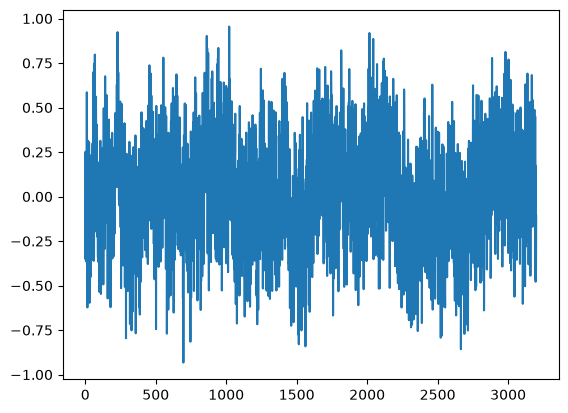

In [13]:
start = int(3.3 * sr)
end   = int(3.5 * sr)

plt.plot(y[start:end])

In [14]:
start = int(3.2 * sr)
end = int(4.0 * sr)

bad = y[start:end]

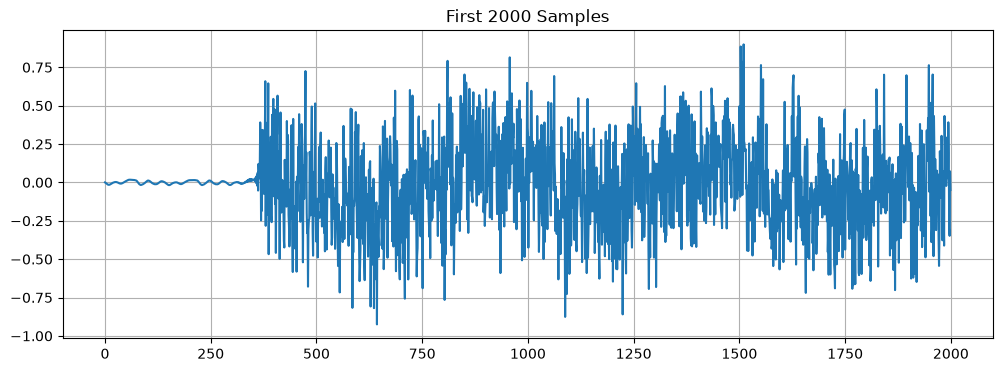

In [14]:
plt.figure(figsize=(12,4))
plt.plot(y[:2000])
plt.title("First 2000 Samples")
plt.grid(True)
plt.show()

Sample rate: 44100
Duration: 5.20s
Min amplitude: -0.0805
Max amplitude: 0.0784
RMS: 0.021270


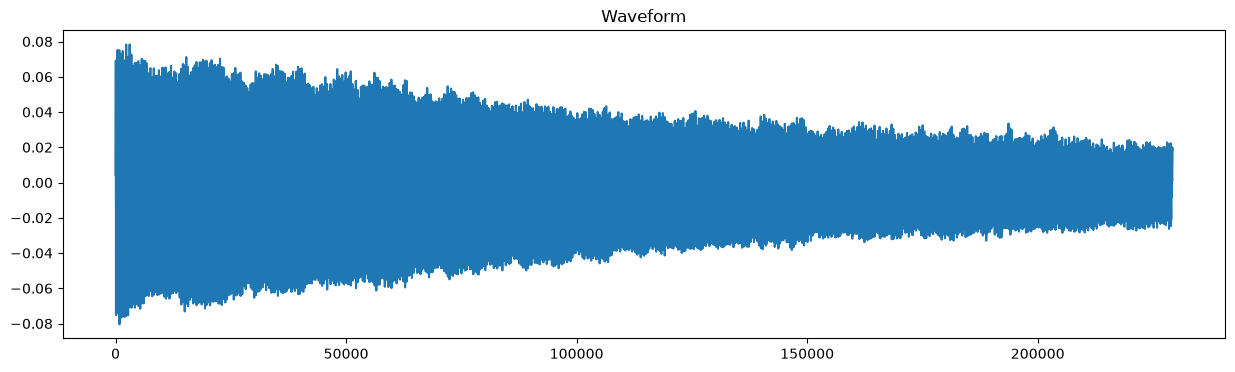

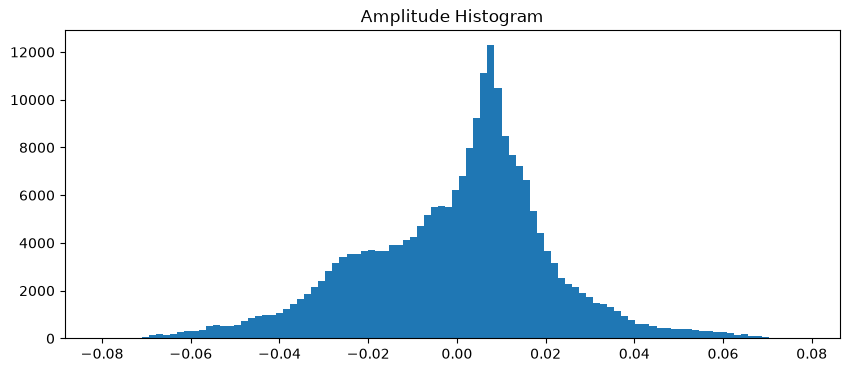

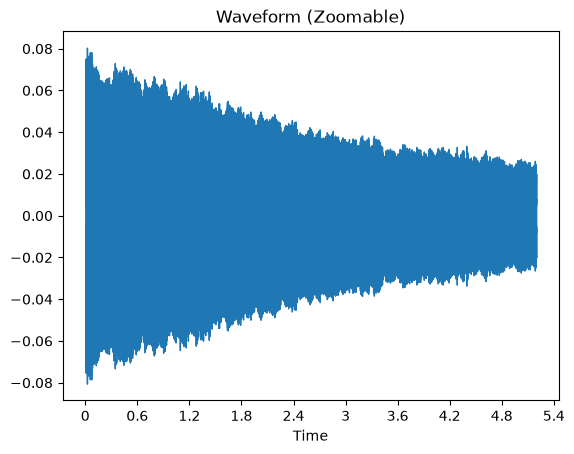

0
0
229208
0.0
0.0


In [36]:
audio_path_2 = r"C:\Users\USER\Desktop\parkinson-detection-cnn-lstm\data\raw_audio\neurovoz\zenodo_upload\audios\PD_O1_0066.wav"

y, sr = librosa.load(audio_path_2, sr=None)

print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.2f}s")
print(f"Min amplitude: {y.min():.4f}")
print(f"Max amplitude: {y.max():.4f}")
print(f"RMS: {np.sqrt(np.mean(y**2)):.6f}")

plt.figure(figsize=(15,4))
plt.plot(y)
plt.title("Waveform")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(y, bins=100)
plt.title("Amplitude Histogram")
plt.show()

librosa.display.waveshow(y, sr=sr)
plt.title("Waveform (Zoomable)")
plt.show()

num_pos = np.sum(y >= 0.999)
num_neg = np.sum(y <= -0.999)

print(num_pos)
print(num_neg)
print(len(y))

print(num_pos / len(y))
print(num_neg / len(y))

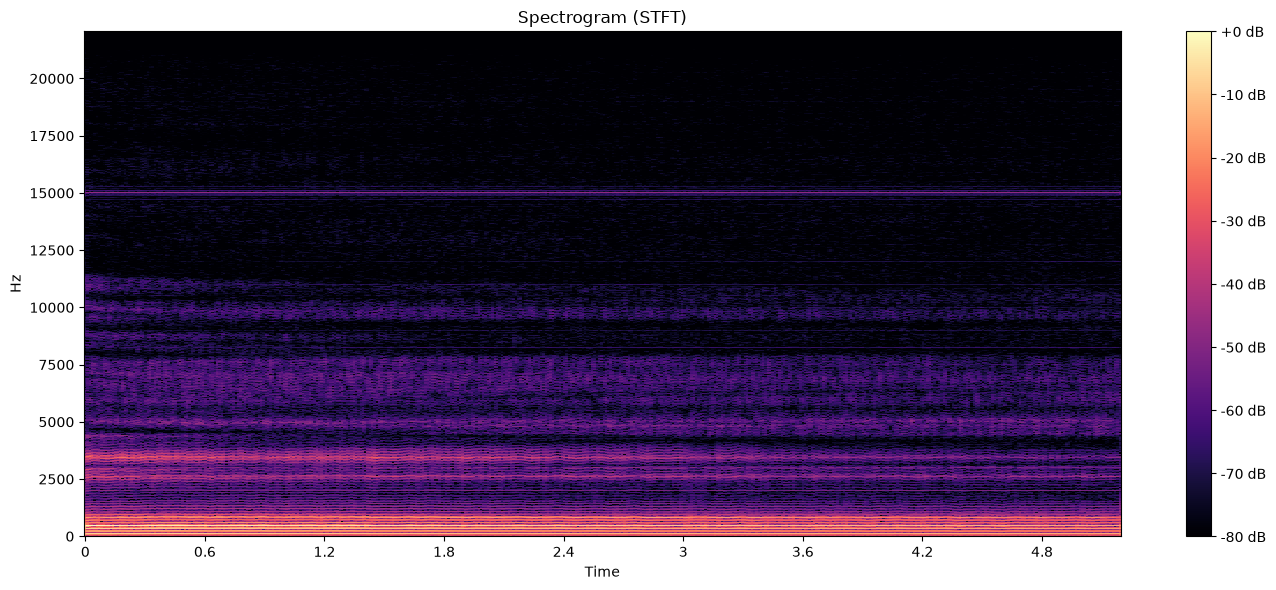

In [37]:
# Compute STFT
D = librosa.stft(
    y,
    n_fft=2048,
    hop_length=512,
    window="hann"
)

# Convert to dB
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

# Plot
plt.figure(figsize=(14, 6))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (STFT)")
plt.tight_layout()
plt.show()

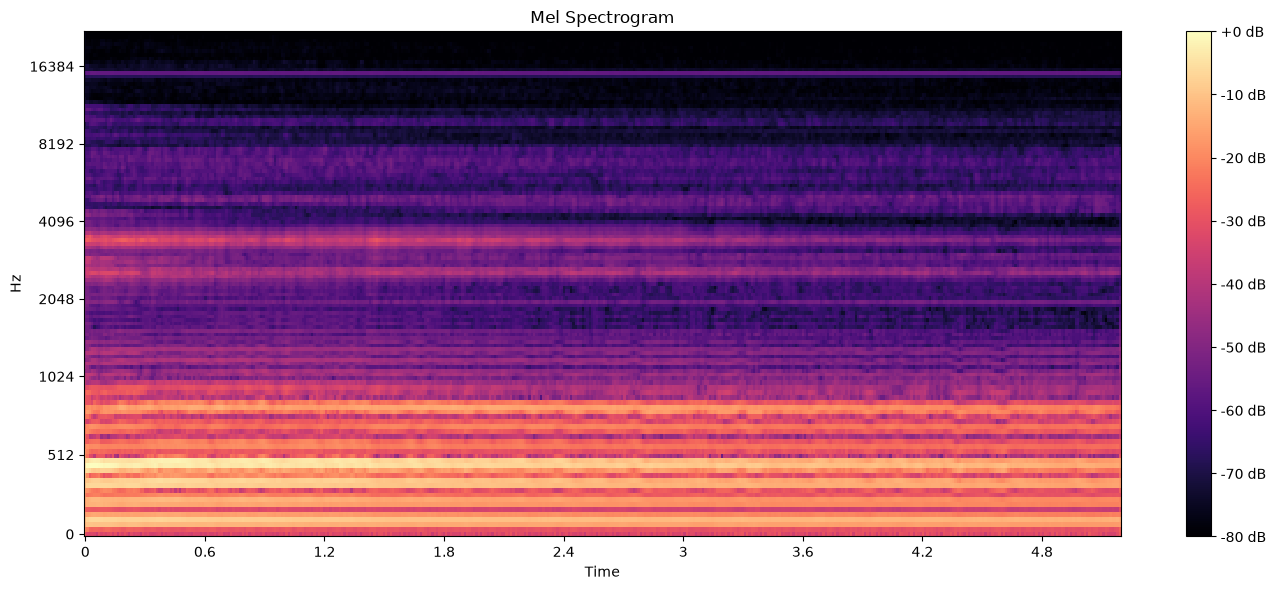

In [40]:
# Compute Mel spectrogram
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    power=2.0
)

# Convert to dB
mel_db = librosa.power_to_db(mel, ref=np.max)

# Plot
plt.figure(figsize=(14, 6))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

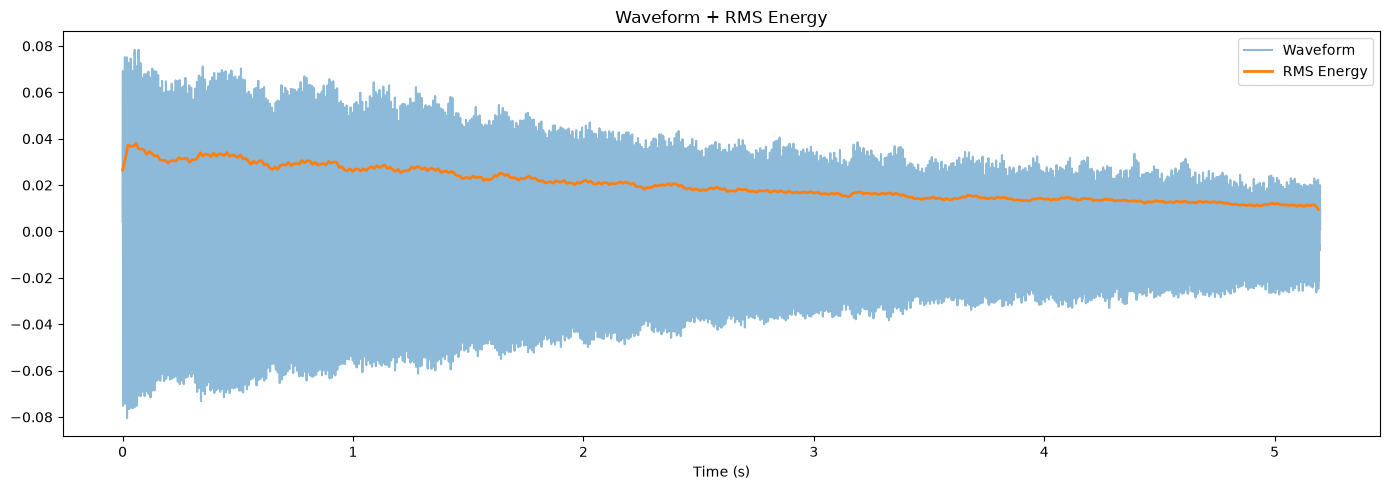

In [39]:
rms = librosa.feature.rms(
    y=y,
    frame_length=2048,
    hop_length=512
)[0]

times = librosa.times_like(rms, sr=sr, hop_length=512)

plt.figure(figsize=(14,5))
plt.plot(np.arange(len(y))/sr, y, alpha=0.5, label="Waveform")
plt.plot(times, rms, linewidth=2, label="RMS Energy")
plt.xlabel("Time (s)")
plt.legend()
plt.title("Waveform + RMS Energy")
plt.tight_layout()
plt.show()

Sample rate: 44100
Duration: 4.28s
Min amplitude: -1.0000
Max amplitude: 1.0000
RMS: 0.241228


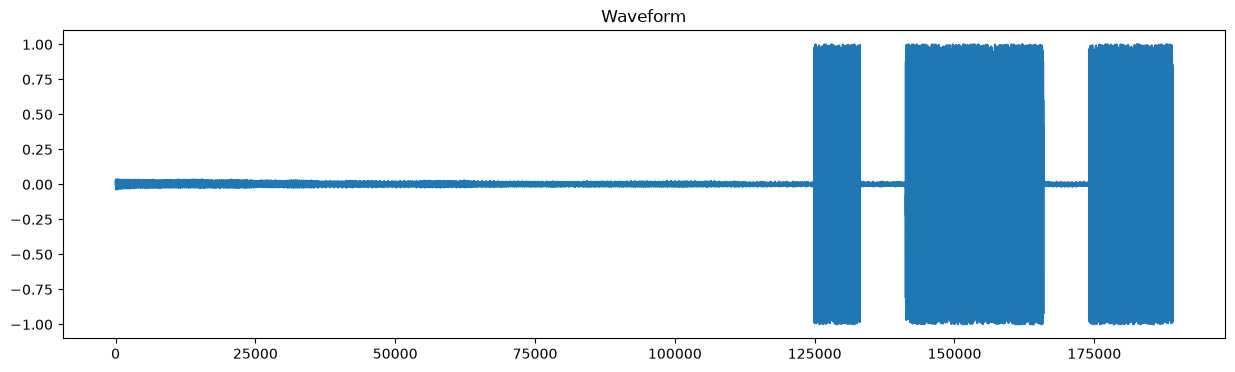

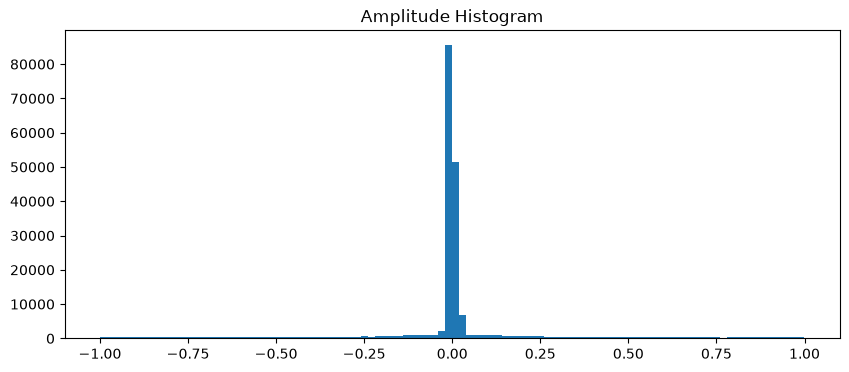

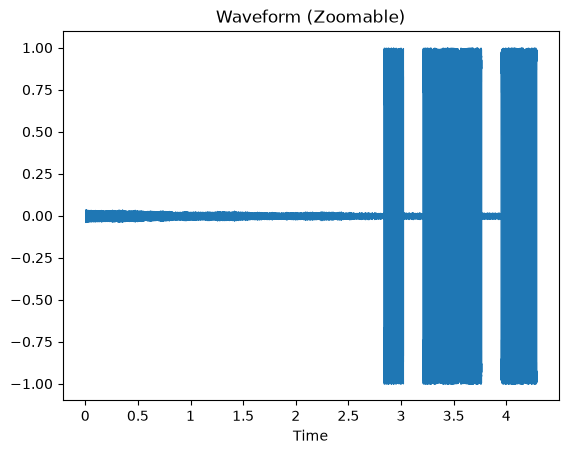

32
22
188958
0.00016934980260163634
0.00011642798928862498


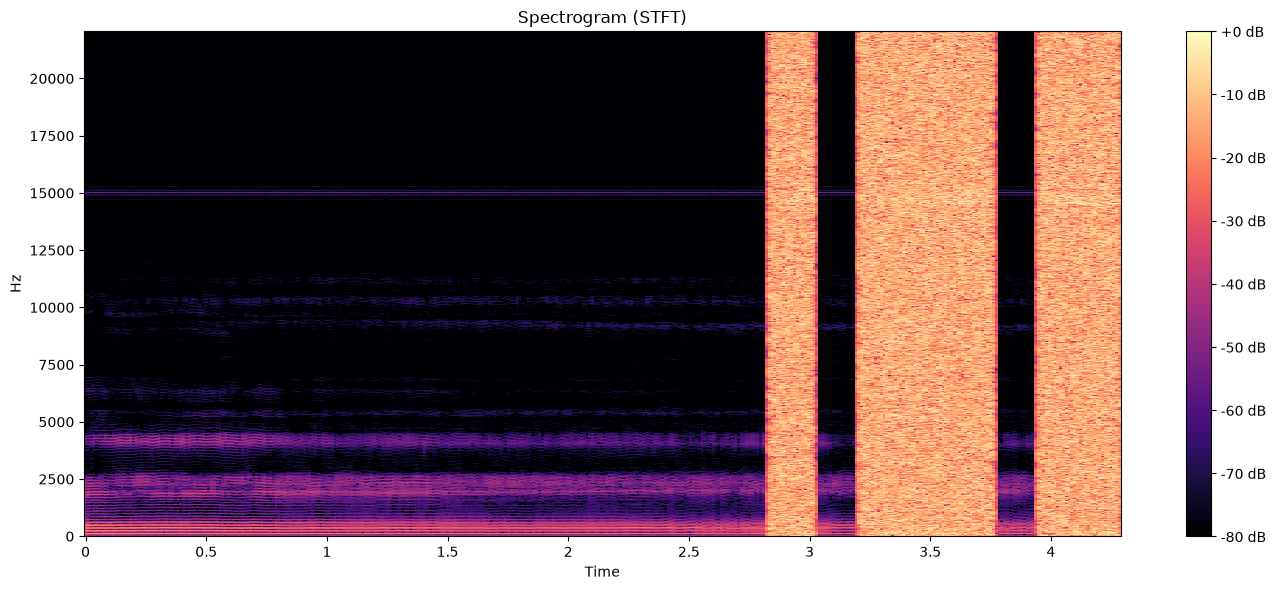

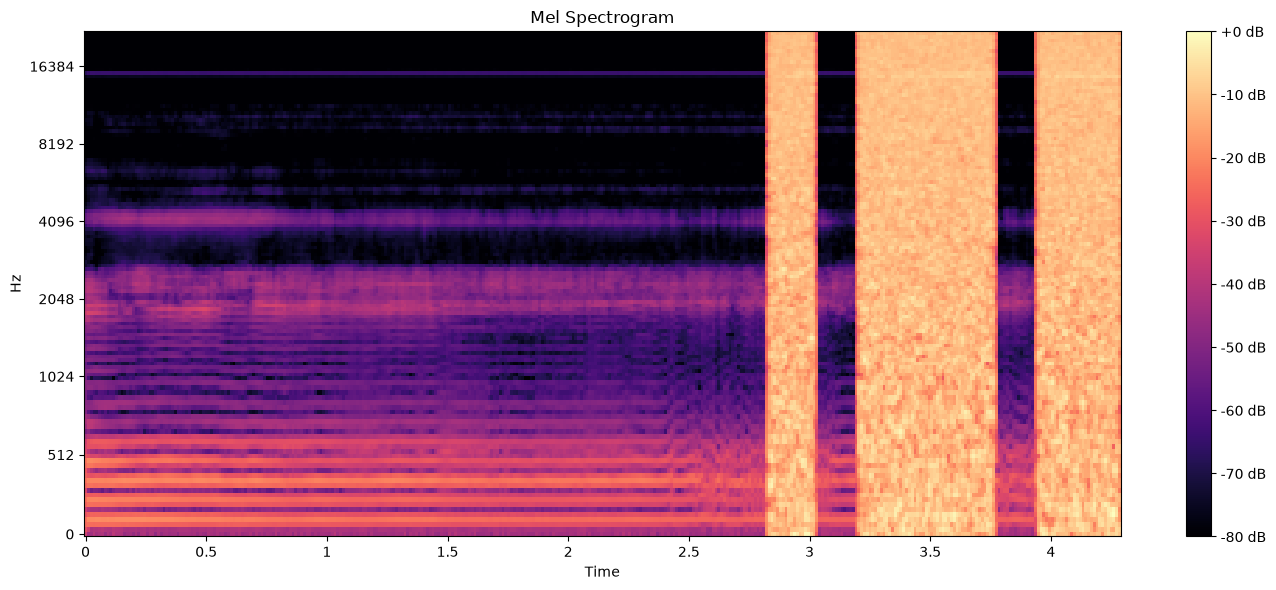

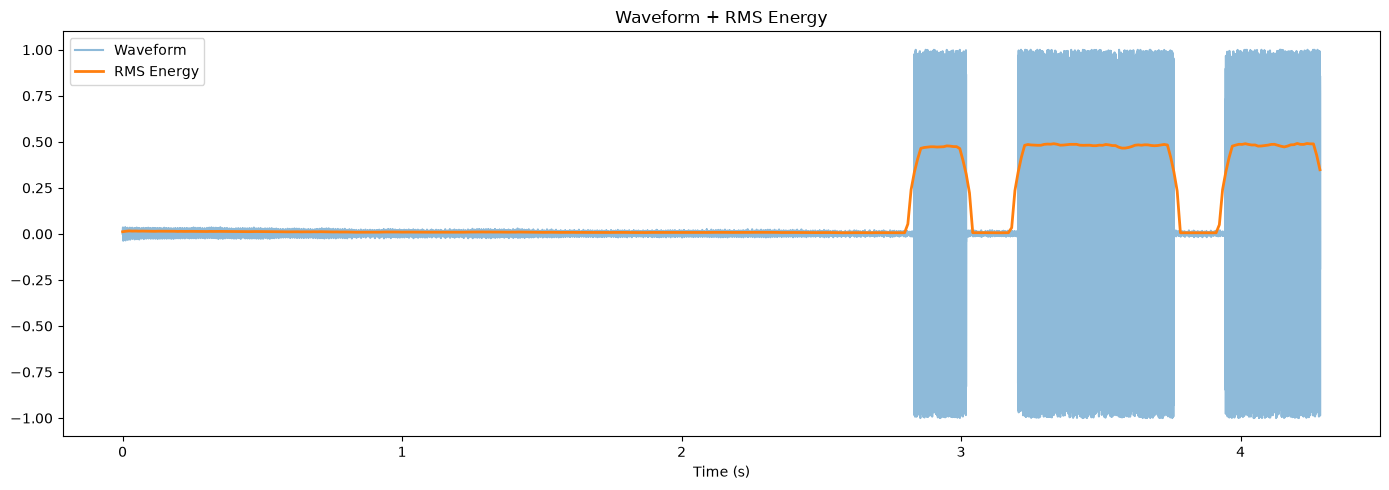

In [4]:
audio_path_3 = r"C:\Users\USER\Desktop\parkinson-detection-cnn-lstm\data\raw_audio\neurovoz\zenodo_upload\audios\PD_E2_0014.wav"

y, sr = librosa.load(audio_path_3, sr=None)

print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.2f}s")
print(f"Min amplitude: {y.min():.4f}")
print(f"Max amplitude: {y.max():.4f}")
print(f"RMS: {np.sqrt(np.mean(y**2)):.6f}")

plt.figure(figsize=(15,4))
plt.plot(y)
plt.title("Waveform")
plt.show()

plt.figure(figsize=(10,4))
plt.hist(y, bins=100)
plt.title("Amplitude Histogram")
plt.show()

librosa.display.waveshow(y, sr=sr)
plt.title("Waveform (Zoomable)")
plt.show()

num_pos = np.sum(y >= 0.999)
num_neg = np.sum(y <= -0.999)

print(num_pos)
print(num_neg)
print(len(y))

print(num_pos / len(y))
print(num_neg / len(y))

# Compute STFT
D = librosa.stft(
    y,
    n_fft=2048,
    hop_length=512,
    window="hann"
)

# Convert to dB
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

# Plot
plt.figure(figsize=(14, 6))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (STFT)")
plt.tight_layout()
plt.show()

# Compute Mel spectrogram
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    power=2.0
)

# Convert to dB
mel_db = librosa.power_to_db(mel, ref=np.max)

# Plot
plt.figure(figsize=(14, 6))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

rms = librosa.feature.rms(
    y=y,
    frame_length=2048,
    hop_length=512
)[0]

times = librosa.times_like(rms, sr=sr, hop_length=512)

plt.figure(figsize=(14,5))
plt.plot(np.arange(len(y))/sr, y, alpha=0.5, label="Waveform")
plt.plot(times, rms, linewidth=2, label="RMS Energy")
plt.xlabel("Time (s)")
plt.legend()
plt.title("Waveform + RMS Energy")
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

# Load processed manifest (or raw_manifest if you prefer)
df = pd.read_csv(r"C:\Users\USER\Desktop\parkinson-detection-cnn-lstm\data\processed_manifest.csv")

print("=" * 60)
print("OVERALL GENDER DISTRIBUTION")
print("=" * 60)
print(df.groupby("subject_id")["gender"].first().value_counts())
print()

# Subject-level dataframe (one row per subject)
subjects = (
    df.groupby("subject_id")
      .agg({
          "gender": "first",
          "label": "first",
          "dataset": "first",
          "age": "first"
      })
      .reset_index()
)

print("=" * 60)
print("GENDER BY DATASET")
print("=" * 60)
print(pd.crosstab(subjects["dataset"], subjects["gender"], margins=True))
print()

print("=" * 60)
print("GENDER BY LABEL")
print("=" * 60)
print(pd.crosstab(subjects["label"], subjects["gender"], margins=True))
print()

print("=" * 60)
print("GENDER BY DATASET + LABEL")
print("=" * 60)
print(
    pd.crosstab(
        [subjects["dataset"], subjects["label"]],
        subjects["gender"],
        margins=True
    )
)

OVERALL GENDER DISTRIBUTION
gender
M    100
F     70
Name: count, dtype: int64

GENDER BY DATASET
gender     F    M  All
dataset               
ipvs      23   39   62
neurovoz  47   61  108
All       70  100  170

GENDER BY LABEL
gender   F    M  All
label               
HC      41   51   92
PD      29   49   78
All     70  100  170

GENDER BY DATASET + LABEL
gender           F    M  All
dataset  label              
ipvs     HC     14   23   37
         PD      9   16   25
neurovoz HC     27   28   55
         PD     20   33   53
All             70  100  170
